<a href="https://colab.research.google.com/github/Nguyen-Quoc-An/TH_DeepLearning/blob/main/Lab5_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Nạp thư viện
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers

In [8]:
# Nạp dataset
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [9]:
# Xây dựng mô hình Autoencoder
encoding_dim = 32
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = layers.Dense(784, activation='sigmoid')(encoded)
autoencoder = keras.Model(input_img, decoded)
encoder = keras.Model(input_img, encoded)
encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [15]:
# Huấn luyện mô hình
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256, verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.0130 - loss: 0.0925 - val_accuracy: 0.0115 - val_loss: 0.0914
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0132 - loss: 0.0925 - val_accuracy: 0.0132 - val_loss: 0.0915
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0128 - loss: 0.0925 - val_accuracy: 0.0126 - val_loss: 0.0914
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0128 - loss: 0.0925 - val_accuracy: 0.0126 - val_loss: 0.0914
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0132 - loss: 0.0925 - val_accuracy: 0.0138 - val_loss: 0.0914
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0127 - loss: 0.0925 - val_accuracy: 0.0129 - val_loss: 0.0914
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0130 - loss: 0.0925 - val_accuracy: 0.0127 - val_loss: 0.0915
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0127 - loss: 0.0925 - val_accu

In [5]:
# Dự báo loại ảnh sử dụng Autoencoder
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


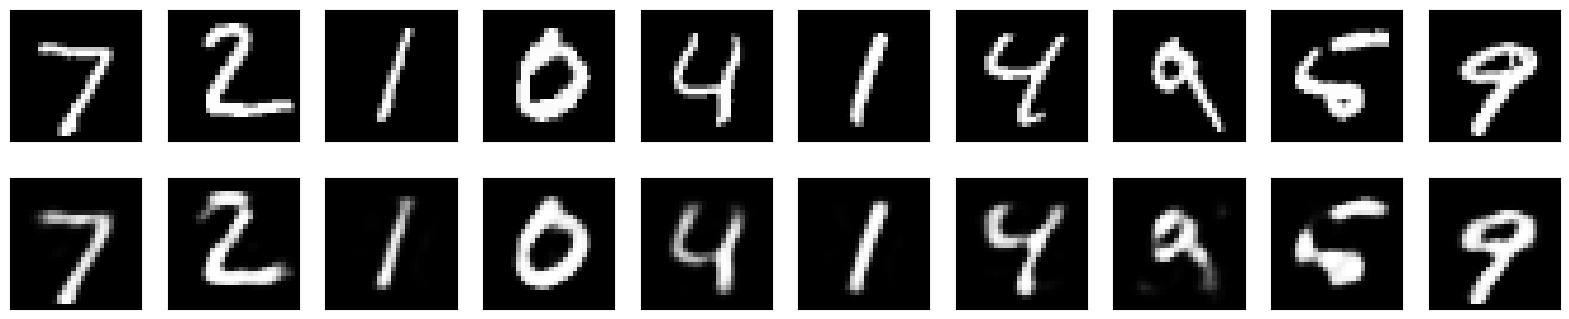

In [12]:
# Hiển thị ảnh từ mô hình Autoencoder
import matplotlib.pyplot as plt
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [18]:
#Thêm L1
import keras
from keras import layers
from keras import regularizers # Khai báo thêm thư viện này

encoding_dim = 32
input_img = keras.Input(shape=(784,))

# "encoded" is the encoded representation of the input
encoded = layers.Dense(encoding_dim, activity_regularizer=regularizers.l1(10e-5), activation='relu')(input_img)

# "decoded" is the lossy reconstruction of the input
decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)
encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [17]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.fit(x_train, x_train,
                epochs=100,
                batch_size=256, verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0141 - loss: 0.6551 - val_accuracy: 0.0143 - val_loss: 0.6155
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0149 - loss: 0.5833 - val_accuracy: 0.0161 - val_loss: 0.5535
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.0150 - loss: 0.5275 - val_accuracy: 0.0161 - val_loss: 0.5038
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.4827 - val_accuracy: 0.0161 - val_loss: 0.4638
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.0150 - loss: 0.4466 - val_accuracy: 0.0161 - val_loss: 0.4314
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0150 - loss: 0.4174 - val_accuracy: 0.0161 - val_loss: 0.4050
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.3935 - val_accuracy: 0.0161 - val_loss: 0.3834
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0150 - loss: 0.3739 - 

In [20]:
encoding_dim = 32
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)
decoded = layers.Dense(784, activation='sigmoid')(encoded)
autoencoder = keras.Model(input_img, decoded)
encoder = keras.Model(input_img, encoded)
encoded_input = keras.Input(shape=(32,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Hình dạng x_train: (50000, 32, 32, 3)
Hình dạng x_test: (10000, 32, 32, 3)


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,347 (52.14 KB)

 Trainable params: 13,347 (52.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 158s 793ms/step - loss: 0.5962 - val_loss: 0.5753
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 198s 771ms/step - loss: 0.5710 - val_loss: 0.5691
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 149s 758ms/step - loss: 0.5671 - val_loss: 0.5669
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 153s 782ms/step - loss: 0.5653 - val_loss: 0.5653
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 196s 750ms/step - loss: 0.5642 - val_loss: 0.5645
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 147s 748ms/step - loss: 0.5634 - val_loss: 0.5637
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 147s 750ms/step - loss: 0.5627 - val_loss: 0.5632
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 147s 750ms/step - loss: 0.5622 - val_loss: 0.5627
Epoch 9/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 201s 748ms/step - loss: 0.5618 - val_loss: 0.5624
Epoch 10/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 204s 756ms/step - loss: 0.5613 - val_loss: 0.5619
Epoch 11/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 203s 759ms/step - loss: 0.5610 - val_loss: 0.5623
Epoch 12

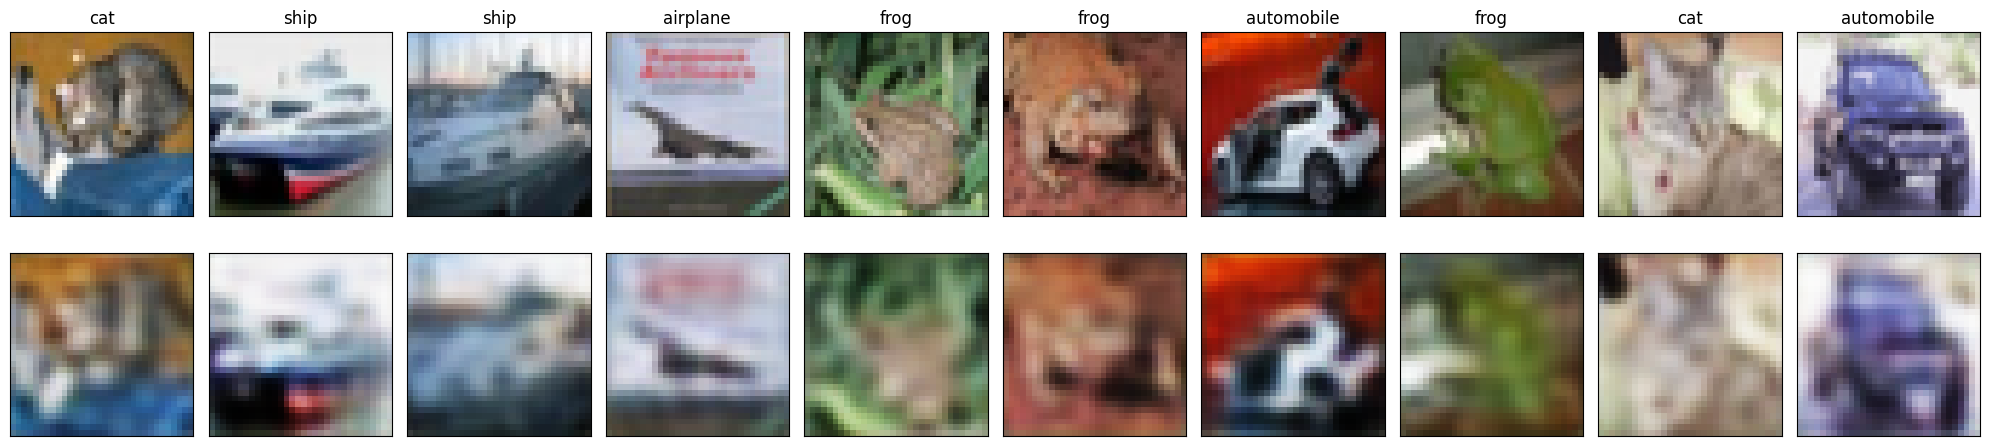

In [21]:
import keras
from keras import layers
from keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt

# 1. Tải và Tiền xử lý dữ liệu CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Chuẩn hóa dữ liệu về khoảng [0, 1] kiểu float32
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Lưu ý: Chúng ta KHÔNG reshape (flatten) dữ liệu như MNIST
# Kích thước giữ nguyên là (số_lượng_ảnh, 32, 32, 3)
print(f"Hình dạng x_train: {x_train.shape}")
print(f"Hình dạng x_test: {x_test.shape}")

# 2. Xây dựng mô hình Convolutional Autoencoder
input_img = keras.Input(shape=(32, 32, 3))

# --- Phần MÃ HÓA (Encoder) ---
# Dùng Conv2D để trích xuất đặc trưng và MaxPooling2D để nén kích thước
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)
# Kích thước không gian lúc này đã bị nén lại thành (8, 8, 16)

# --- Phần GIẢI MÃ (Decoder) ---
# Dùng UpSampling2D để khôi phục lại kích thước ban đầu
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

# Lớp đầu ra dùng 3 filter tương ứng với 3 kênh màu (R, G, B)
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# Gom lại thành mô hình hoàn chỉnh
autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# In ra tóm tắt kiến trúc mạng
autoencoder.summary()

# 3. Huấn luyện mô hình
# (Bạn có thể tăng số epochs lên 50 hoặc 100 nếu muốn ảnh nét hơn)
autoencoder.fit(x_train, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# 4. Dự đoán và Hiển thị Kết quả
decoded_imgs = autoencoder.predict(x_test)

# Định nghĩa dictionary nhãn từ bảng mô tả
cifar10_labels = {
    0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
    5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

n = 10  # Số lượng ảnh hiển thị
plt.figure(figsize=(20, 5))
for i in range(n):
    # --- Hiển thị ảnh gốc ---
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    # Lấy nhãn tương ứng để làm tiêu đề
    label_index = y_test[i][0]
    plt.title(cifar10_labels[label_index])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # --- Hiển thị ảnh tái tạo ---
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()